In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv('Student Academic Performance.csv')
df.head()

,Timestamp,Email Address,Student Name,Age,Gender,Study Hours Per Day,Attendance Percentage,Sleep Hours Per Day,Internet Usage Hours Per Day,What is your primary method of learning/studying?,Tuition_Class,Final_Exam_Percentage
0,18-02-2026 14:09,ptwinkle837@gmail.com,Patel Twinkle,21,Female,8,89.0,8,4,"Watching educational videos, Practicing proble...",No,91.0
1,18-02-2026 14:12,pateljainam3432@gmail.com,Jainam patel,17,Male,5,85.0,7,1,Reading textbooks/notes,Yes,86.2
2,18-02-2026 14:26,krishapatel10022006@gmail.com,Patel Krisha,20,Female,9,85.0,6,2,Group study/Discussion,No,90.0
3,18-02-2026 14:27,diyat1920@gmail.com,Diya Patel,20,Female,8,85.0,8,3,Practicing problems/exercises,No,90.0
4,18-02-2026 14:28,deeppatel15530@gmail.com,patel Deep MaheshBhai,22,Male,4,75.0,6,4,Other,Yes,80.0


In [38]:
df.tail()

,Timestamp,Email Address,Student Name,Age,Gender,Study Hours Per Day,Attendance Percentage,Sleep Hours Per Day,Internet Usage Hours Per Day,What is your primary method of learning/studying?,Tuition_Class,Final_Exam_Percentage
115,19-02-2026 03:45,amitprajapati1996@live.com,Patel urvi,20,Female,6,70.0,8,3,"Watching educational videos, Other",No,7.5
116,19-02-2026 03:53,babeg2808@gmail.com,Rajbhar tejee,21,Female,5,70.0,8,5,"Reading textbooks/notes, Watching educational ...",No,70.0
117,19-02-2026 05:21,prashu.bhagat07@gmail.com,Prashant Bhagat,20,Male,3,99.0,6,3,Watching educational videos,No,70.0
118,19-02-2026 05:25,hetvid52@gmail.com,Dave hatvi,21,Female,1,20.0,10,5,"Group study/Discussion, Other",No,75.0
119,19-02-2026 05:59,hetvishah0604@gmail.com,Shah Hetvi Ileshkumar,19,Female,2,90.0,7,3,"Reading textbooks/notes, Watching educational ...",No,85.0


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Timestamp                                          120 non-null    str    
 1   Email Address                                      120 non-null    str    
 2   Student Name                                       120 non-null    str    
 3   Age                                                120 non-null    int64  
 4     Gender                                           120 non-null    str    
 5   Study Hours Per Day                                120 non-null    str    
 6   Attendance Percentage                              120 non-null    float64
 7   Sleep Hours Per Day                                120 non-null    str    
 8   Internet Usage Hours Per Day                       120 non-null    str    
 9   What is your primary 

In [40]:
df.describe()

,Age,Attendance Percentage,Final_Exam_Percentage
count,120.000000,120.000000,120.000000
mean,21.116667,75.279167,69.007583
std,2.369921,16.012584,19.119065
min,17.000000,20.000000,7.500000
25%,20.000000,65.775000,55.150000
50%,21.000000,77.350000,74.000000
75%,23.000000,88.475000,82.775000
max,25.000000,99.700000,97.500000


In [41]:
df.isnull().sum()

Timestamp                                            0
Email Address                                        0
Student Name                                         0
Age                                                  0
  Gender                                             0
Study Hours Per Day                                  0
Attendance Percentage                                0
Sleep Hours Per Day                                  0
Internet Usage Hours Per Day                         0
What is your primary method of learning/studying?    0
Tuition_Class                                        3
  Final_Exam_Percentage                              0
dtype: int64

In [42]:
df = df.dropna()

In [43]:
df.isnull().sum()

Timestamp                                            0
Email Address                                        0
Student Name                                         0
Age                                                  0
  Gender                                             0
Study Hours Per Day                                  0
Attendance Percentage                                0
Sleep Hours Per Day                                  0
Internet Usage Hours Per Day                         0
What is your primary method of learning/studying?    0
Tuition_Class                                        0
  Final_Exam_Percentage                              0
dtype: int64

In [44]:
# Get all object/str columns
cols = df.select_dtypes(include=['object', 'string']).columns

for col in cols:
    # Convert everything to string
    df[col] = df[col].astype(str)
    # Encode to integers
    df[col], _ = pd.factorize(df[col])

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 117 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Timestamp                                          117 non-null    int64  
 1   Email Address                                      117 non-null    int64  
 2   Student Name                                       117 non-null    int64  
 3   Age                                                117 non-null    int64  
 4     Gender                                           117 non-null    int64  
 5   Study Hours Per Day                                117 non-null    int64  
 6   Attendance Percentage                              117 non-null    float64
 7   Sleep Hours Per Day                                117 non-null    int64  
 8   Internet Usage Hours Per Day                       117 non-null    int64  
 9   What is your primary metho

## 1.Simple Linear Regression

In [46]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [47]:
X = df.drop("Final_Exam_Percentage", axis=1)
y = df["Final_Exam_Percentage"]

In [48]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_single = df[['Study_Hours_Per_Day']]

x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(X_single, y, test_size=0.2, random_state=42)

lr_simple = LinearRegression()
lr_simple.fit(x_train_s, y_train_s)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred_s = lr_simple.predict(x_test_s)

print("Simple Linear R2 Score:", r2_score(y_test_s, y_pred_s))

Simple Linear R2 Score: 0.06419294849772028


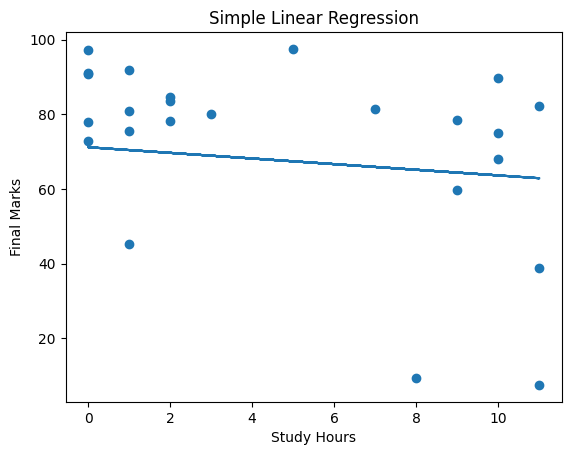

In [59]:
plt.scatter(x_test_s, y_test_s)
plt.plot(x_test_s, y_pred_s)
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Simple Linear Regression")
plt.show()

## 2. Multiple Linear Regression

In [51]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
y_pred = lr.predict(x_test)

print("Multiple Linear R2 Score:", r2_score(y_test, y_pred))

Multiple Linear R2 Score: 0.04243992179512479


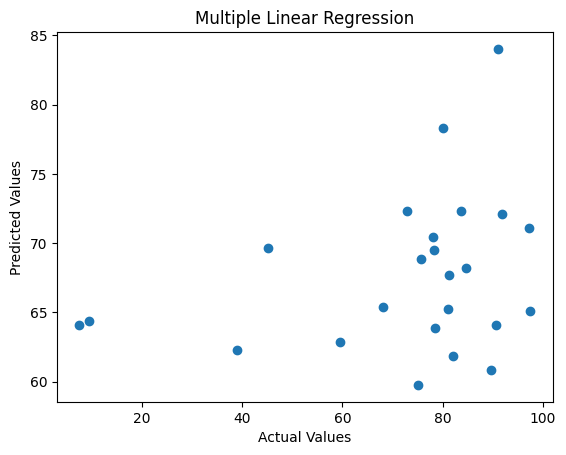

In [60]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression")
plt.show()

## 3. Decision Tree (Regression)

In [56]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [57]:
y_pred_dt = dt.predict(x_test)

print("Decision Tree R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree R2 Score: -0.7570022837407171


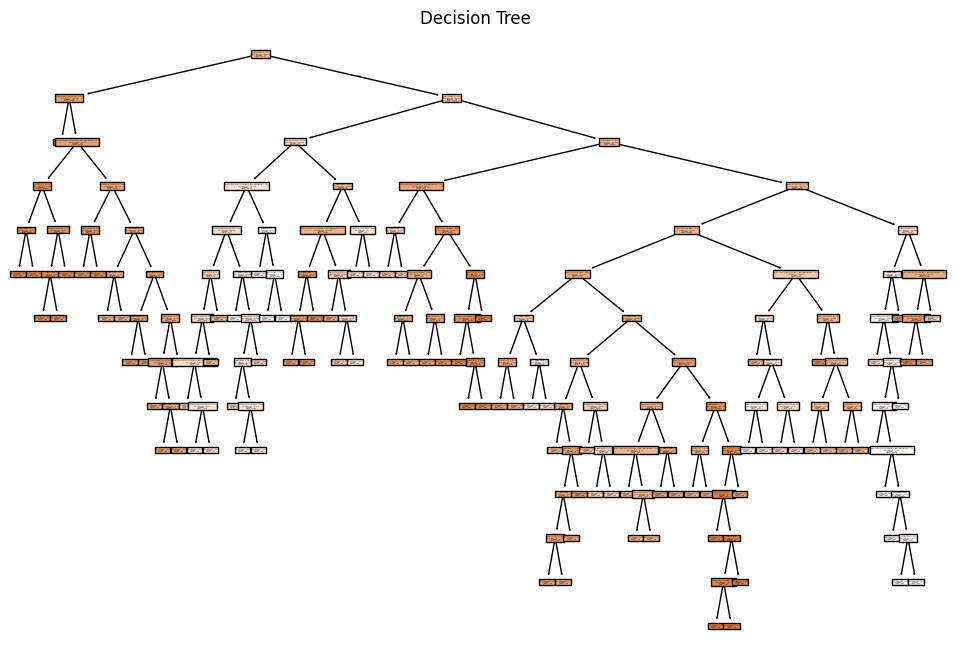

In [61]:
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, feature_names=X.columns)
plt.title("Decision Tree")
plt.show()

## 4. Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df['Result'] = (df['Final_Exam_Percentage'] > 50).astype(int)

X_cls = df.drop(['Final_Exam_Percentage', 'Result'], axis=1)
y_cls = df['Result']

In [32]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [33]:
log = LogisticRegression(max_iter=1000)
log.fit(x_train_c, y_train_c)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_pred_log = log.predict(x_test_c)

print("Logistic Regression Accuracy:", accuracy_score(y_test_c, y_pred_log))

Logistic Regression Accuracy: 0.75


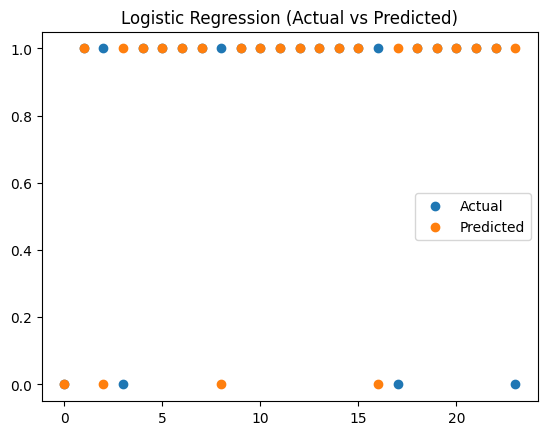

In [62]:
plt.scatter(range(len(y_test_c)), y_test_c, label="Actual")
plt.scatter(range(len(y_pred_log)), y_pred_log, label="Predicted")
plt.legend()
plt.title("Logistic Regression (Actual vs Predicted)")
plt.show()